# 딥러닝응용I(추천시스템) · W03A
**동덕여자대학교 데이터사이언스전공 · 유원상 교수 · 2026년 2학기**

## 협업 필터링의 기본 원리와 유사도 기반 추천 · 2026-09-15
평점 행렬을 읽고 코사인·Pearson·Jaccard를 비교한다. 기본 사용자 기반 CF를
실제 MovieLens 100K에서 평가하고, 이전 웹 앱에 추천과 근거 표시를 추가한다.
`None`은 직접 완성할 부분이다. 미완성이어도 다음 독립 실습을 실행할 수 있다.
교재 3.1–3.3이 본 범위이며 Pearson 기반 예측 비교는 선택 심화다.

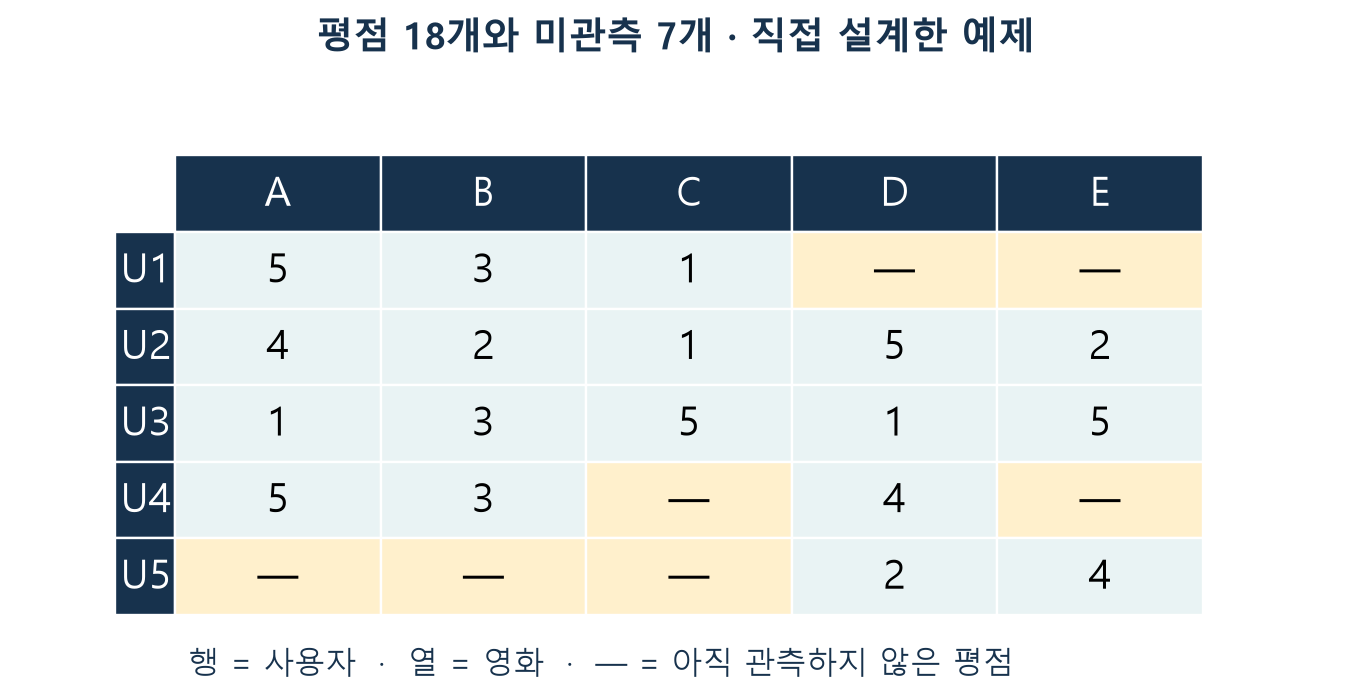


[Figure source](https://raw.githubusercontent.com/lunalab-ai/recommender/2026-fall-w03a/course/notion/assets/w03a/02-rating-matrix.png)


## 1. 실행 환경
Colab에서는 현재 커널의 Python(`sys.executable`)에 고정 수업 버전을 설치한다.
`subprocess.run(..., check=True)`는 설치 실패를 즉시 알린다. `[apps]`는 웹 앱용
Gradio를 포함한다. 처음부터 순서대로 실행하며, 설치 후 재시작 안내가 나타나면
런타임을 다시 시작하고 첫 셀부터 실행한다. 검토 단계에는 아래 태그가 아직
공개되지 않아 Colab 설치가 불가능하다. 로컬 실행은 실제 Colab UI 확인과 구별한다.
데이터 업로드나 API 키는 필요 없다. `os.getenv`는 선택 환경 변수,
`Path`는 운영체제에 맞는 파일 경로를 뜻한다.


In [ ]:
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
COURSE_VERSION = "2026-fall-w03a"
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
        f"luna-recommender-course[apps] @ git+https://github.com/lunalab-ai/recommender.git@{COURSE_VERSION}"], check=True)
else:
    print("로컬 저작 패키지 실행. 공개 태그 설치·Colab UI 검증은 별도입니다.")


## 2. API를 읽고 작은 행렬부터 시작하기
`numpy`는 배열 계산, `pandas`는 행·열 표, `display`는 notebook 표 출력을 담당한다.
`toy_ratings()`는 독자적으로 만든 5명×5편의 관측 평점 18행을 반환한다.
`pivot`의 행은 사용자, 열은 영화이며 관측되지 않은 칸은 `NaN`이다.
`UserCF(metric="cosine", min_common=3)`는 모델 설정만 만든다.
`.fit(train)`은 `user_id/movie_id/rating` 열을 가진 유일한 관측 쌍(1–5점)을 받아
유사도·평균·관측 마스크를 학습하고 자기 자신을 반환한다. ID는 정수다.
`.rating_matrix_`, `.similarity_`는 학습 후 확인하는 DataFrame이다.
[함수별 입력·출력·정의 위치](https://github.com/lunalab-ai/recommender/blob/2026-fall-w03a/src/W03A-API.md)


In [ ]:
import numpy as np
import pandas as pd
from IPython.display import display
from luna_recsys.collaborative import UserCF, toy_ratings, binary_jaccard

toy = toy_ratings()
small = UserCF().fit(toy)
R = small.rating_matrix_
display(R.rename(columns=dict(enumerate("ABCDE", start=1))))


### E1 · 관측 집합 읽기
$I_u$는 사용자 $u$가 평가한 영화 집합이다. U1과 U4가 함께 평가한 영화
$I_{14}=I_1\cap I_4$를 영화 ID 집합으로 적고, 관측이 없는 칸을 0점으로
평균에 포함하면 안 되는 이유를 설명하라. 힌트: `dropna().index`는 관측 열이다.


In [ ]:
common_14 = None
if common_14 is None:
    print("E1: 공통 영화 ID의 집합을 입력하세요.")
else:
    assert common_14 == set(R.loc[1].dropna().index) & set(R.loc[4].dropna().index)


## 3. 코사인: 방향의 유사성
같은 차원의 벡터 $x,y$와 좌표 $j$에 대해
$$s(x,y)=\frac{\sum_j x_jy_j}{\sqrt{\sum_j x_j^2}\sqrt{\sum_j y_j^2}}.$$
영벡터의 코사인은 수학적으로 정의되지 않는다. 일반 벡터는 −1~1,
음수가 없는 평점 벡터는 0~1이다. `np.dot`은 내적, `np.linalg.norm`은 길이다.
기본 CF는 전체 영화 차원에서 미관측을 계산용 0으로 채운다. 양쪽 길이는
각자의 모든 관측으로 계산하므로 공통 영화에만 한정한 코사인과 다를 수 있다.
`R`을 전치하면 사용자 대신 영화 사이 유사도를 계산하는 문제가 된다.

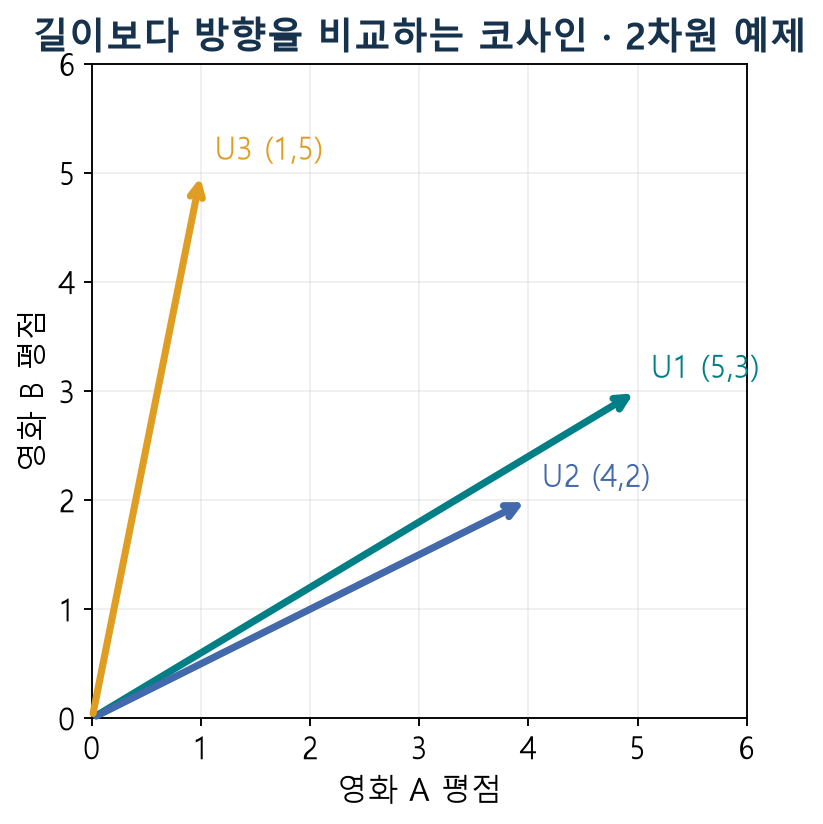


[Figure source](https://raw.githubusercontent.com/lunalab-ai/recommender/2026-fall-w03a/course/notion/assets/w03a/03-cosine-angle.png)


### E2 · 내적과 노름
$x=(1,2), y=(2,1)$의 코사인을 먼저 예상하고 계산식을 완성하라.
두 벡터가 같지 않아도 유사도가 양수가 되는 이유를 설명하라.


In [ ]:
x = np.array([1., 2.])
y = np.array([2., 1.])
cos_xy = None
if cos_xy is None:
    print("E2: 내적을 두 노름의 곱으로 나누세요.")
else:
    assert np.isclose(cos_xy, np.dot(x, y)/(np.linalg.norm(x)*np.linalg.norm(y)))


## 4. Pearson과 행동 집합
Pearson은 공통 평가 집합 $I_{uv}$에서 각각의 평균 $\bar r_{u\mid uv}$를 뺀
편차 벡터의 코사인이다. 평균을 빼는 범위를 양쪽에서 같게 잡아야 한다.
$$s_P(u,v)=\frac{\sum_{j\in I_{uv}}(r_{uj}-\bar r_{u\mid uv})(r_{vj}-\bar r_{v\mid uv})}{\sqrt{\sum_{j\in I_{uv}}(r_{uj}-\bar r_{u\mid uv})^2}\sqrt{\sum_{j\in I_{uv}}(r_{vj}-\bar r_{v\mid uv})^2}}.$$
상수 벡터는 편차의 길이가 0이므로 정의되지 않는다. 공통 표본 2개만으로
±1이 나오기 쉬워 이 수업의 선택 모델은 최소 공통 3개를 요구한다.

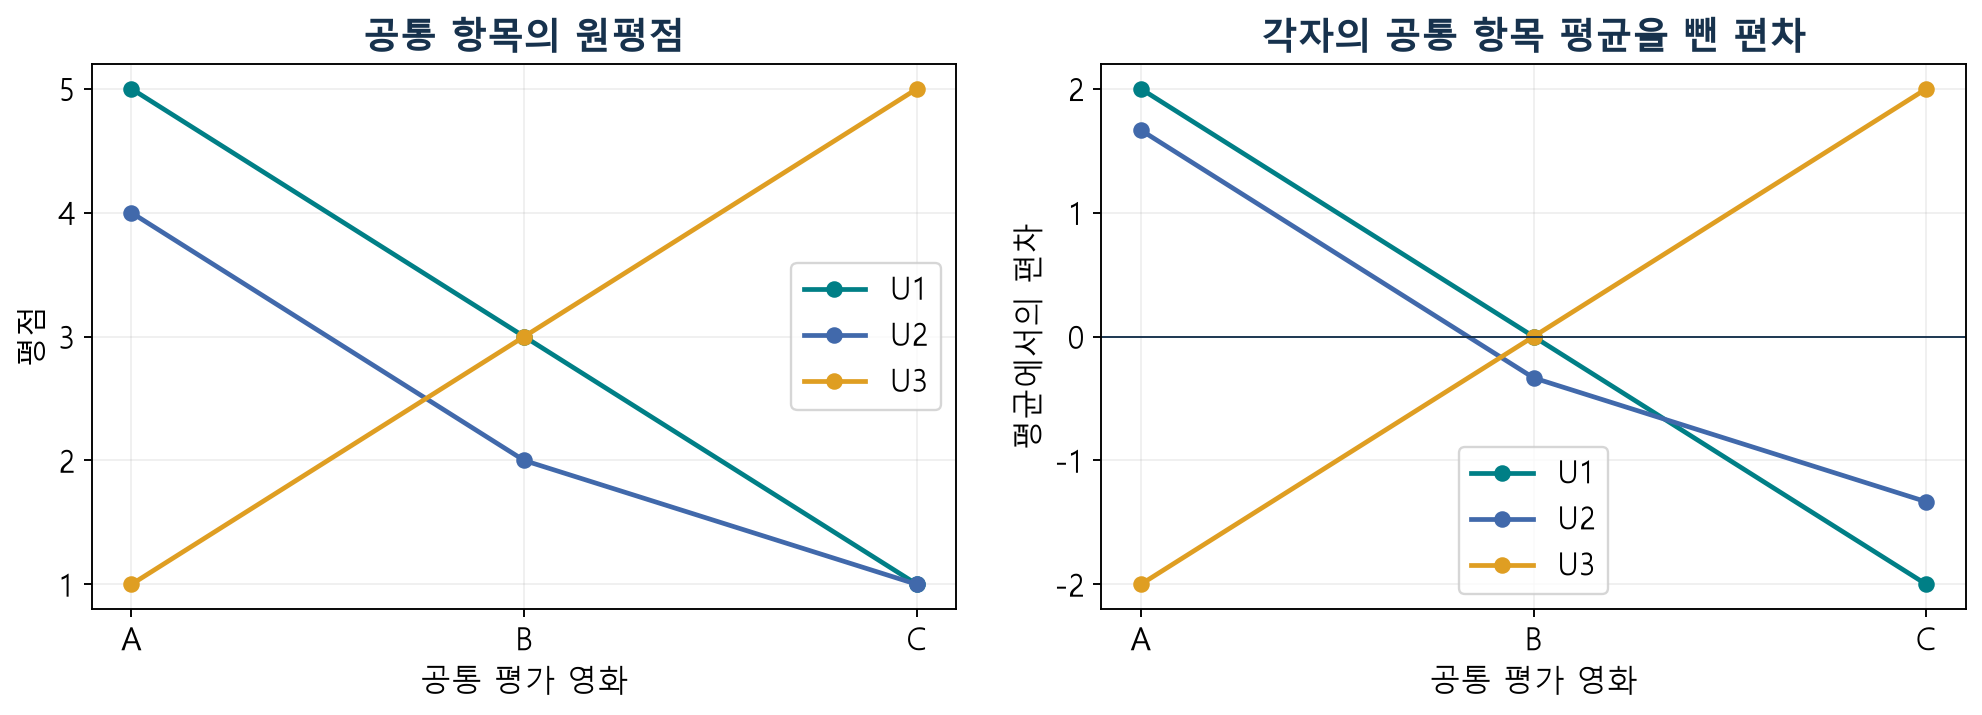


[Figure source](https://raw.githubusercontent.com/lunalab-ai/recommender/2026-fall-w03a/course/notion/assets/w03a/04-pearson-centering.png)


### E3 · 반대 패턴과 상수
$a=(1,2,3), b=(3,2,1)$의 Pearson 값을 예상하라. $b$를 $(2,2,2)$로
바꾸면 왜 0이라고 답하면 안 되는가? `pearson_ab`에 첫 값을 적는다.


In [ ]:
a, b = np.array([1., 2., 3.]), np.array([3., 2., 1.])
pearson_ab = None
if pearson_ab is None:
    print("E3: 평균을 뺀 두 벡터의 방향을 비교하세요.")
else:
    assert np.isclose(pearson_ab, np.corrcoef(a, b)[0, 1])


### E4 · 이진 Tanimoto/Jaccard
행동 집합 $A,B$의 유사도는 $J(A,B)=|A\cap B|/|A\cup B|$다.
`binary_jaccard(A,B)`는 두 `set`을 받아 0~1의 수를 반환하고, 둘 다 비면
`np.nan`을 반환한다. 이 API는 일반 실수 벡터용 Tanimoto가 아니다.
A={A,B,C,D}, B={C,D,E}의 교집합과 합집합 크기를 적고 유사도를 계산하라.
이진 벡터에도 코사인을 계산할 수 있지만 분모와 해석이 달라진다.


In [ ]:
actions_a, actions_b = set("ABCD"), set("CDE")
jaccard_value = None
if jaccard_value is None:
    print("E4: 공통 행동 수 / 한 명이라도 한 행동 수를 계산하세요.")
else:
    assert np.isclose(jaccard_value, binary_jaccard(actions_a, actions_b))


## 5. 기본 CF: 목표 영화를 평가한 사람만 가중평균
$V_{ui}$는 자신을 제외하고 영화 $i$를 평가했으며 $s(u,v)>0$인 사용자 집합이다.
$$w_{uvi}=\frac{s(u,v)}{\sum_{z\in V_{ui}}s(u,z)},\qquad \widehat r_{ui}=\sum_{v\in V_{ui}}w_{uvi}r_{vi}.$$
정규화 가중치 합은 1이다. 본 알고리즘은 모든 적격 평가자를 사용한다.
이웃 top-k는 다음 차시다. 근거가 없으면 train 영화 평균, 영화도 처음이면
train 전체 평균으로 대체한다. 선택 Pearson 모델은 양의 상관만 원평점에
가중하며, 평균 보정형 예측식과 구별한다.
`.predict_details(pairs)`는 ID 두 열을 받아 prediction/basis/n_contributors/weight_sum을
입력 순서대로 반환한다. `.explain(u,i)`는 실제 기여자의 유사도·평점·가중치·기여도 표를 반환한다.

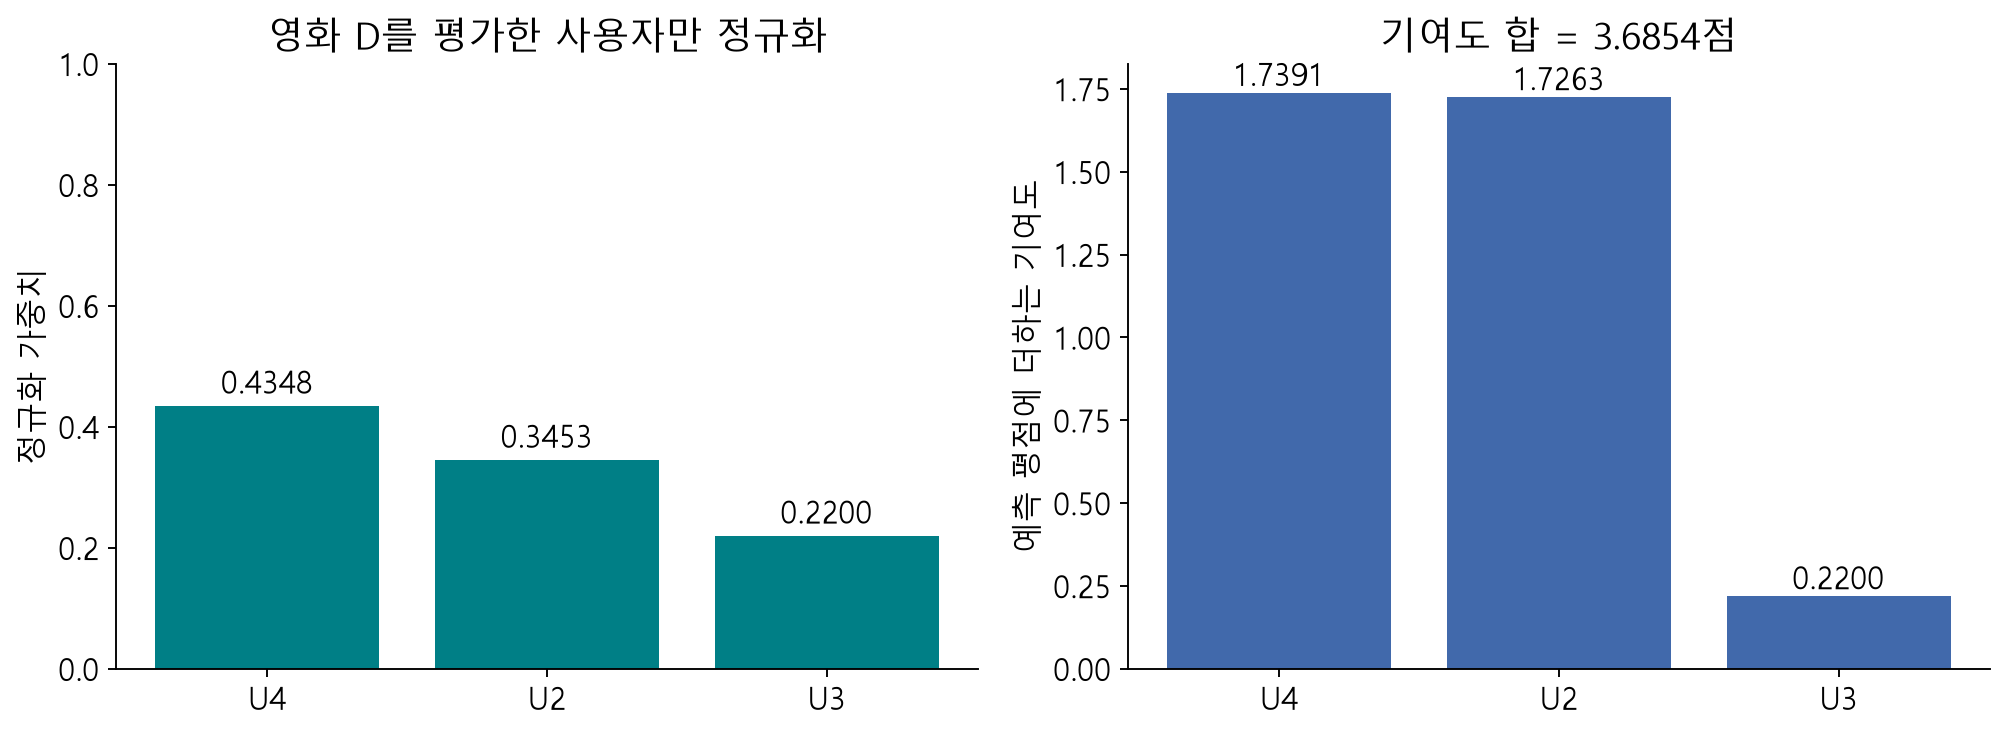


[Figure source](https://raw.githubusercontent.com/lunalab-ai/recommender/2026-fall-w03a/course/notion/assets/w03a/07-weighted-contributions.png)


In [ ]:
display(small.similarity_.round(4))
display(small.predict_details(pd.DataFrame({"user_id":[1], "movie_id":[4]})))
display(small.explain(1, 4).round(4))


### E5 · 분모 마스크 버그 고치기
세 후보 사용자의 유사도는 (0.8,0.5,0.2), 목표 영화 평점은 (5,미관측,1)이다.
미관측을 분자에서만 제외하고 분모를 1.5로 두는 코드는 잘못되었다.
`valid_mask`를 완성하고 올바른 예측과 잘못된 예측이 얼마나 다른지 기록하라.
`np.isfinite`는 유한한 수인지 확인한다. 같은 마스크로 분자와 분모를 선택한다.


In [ ]:
sim = np.array([.8, .5, .2])
target_rating = np.array([5., np.nan, 1.])
valid_mask = None
if valid_mask is None:
    print("E5: 관측 평점이 있고 유사도가 양수인 위치를 선택하세요.")
else:
    exercise_prediction = np.dot(sim[valid_mask], target_rating[valid_mask])/sim[valid_mask].sum()
    display(pd.DataFrame({"prediction":[exercise_prediction]}))


## 6. 실제 MovieLens 100K와 동일 holdout
`prepare_movielens(cache_dir, local_dir=None, mode="real")`는 캐시 또는 공식 다운로드로
자료를 준비하고 `.data/.mode/.description`을 반환한다. `real`은 실패를 합성 자료로
숨기지 않는다. local_dir는 교수자 검증용 선택값이며 학생은 지정하지 않는다.
`split_ratings(ratings, test_size=.25, seed=42)`는 가능한 사용자 층화로 train/test를
나눈 객체를 반환한다. 같은 관측 쌍은 겹치지 않는다. 시간 순 미래 예측은 아니다.
`MeanRatingPredictor("movie")`는 이전 수업의 영화 평균 기준선이다.
`.predict(pairs)`는 평점 정답 없이 예측 배열을 반환한다. RMSE 함수는
실제 평점과 예측을 받아 같은 평점 단위의 오차 하나를 반환한다.
[데이터 준비 정의](https://github.com/lunalab-ai/recommender/blob/2026-fall-w03a/src/luna_recsys/datasets.py)
· [분할 정의](https://github.com/lunalab-ai/recommender/blob/2026-fall-w03a/src/luna_recsys/evaluation.py)


In [ ]:
from luna_recsys.datasets import prepare_movielens
from luna_recsys.evaluation import split_ratings
from luna_recsys.rating_models import MeanRatingPredictor
from sklearn.metrics import root_mean_squared_error

cache = Path("/content/recommender-data") if IN_COLAB else Path.home()/".cache/luna-recsys"
prepared = prepare_movielens(cache, local_dir=os.getenv("RECOMMENDER_DATA_DIR") or None, mode="real")
data = prepared.data
split = split_ratings(data.ratings, test_size=.25, seed=42)
train, test = split.train, split.test
pairs = test[["user_id", "movie_id"]]
print(prepared.description)
print("users/movies/ratings:", len(data.users), len(data.movies), len(data.ratings))
print("train/test:", len(train), len(test), split.method)


### E6 · 평가 누수 찾기
`UserCF().fit(data.ratings)`로 학습한 뒤 `test`를 평가하려는 계획에서 한 줄을
어떻게 고쳐야 하는가? `training_choice`에 사용할 변수 이름을 문자열로 적는다.
힌트: test의 실제 평점은 마지막 오차 계산에만 사용한다. 전체 자료의
평점으로 만든 유사도도 이미 정답을 보았다는 점을 설명하라.


In [ ]:
training_choice = None
if training_choice is None:
    print("E6: 사용할 학습 변수와 그 이유를 적으세요.")
else:
    print("선택:", training_choice, "— train/test 관측 분리를 확인하세요.")


아래는 독립 실행 가능한 기준 실험이다. 모든 방법은 같은 분할을 사용한다.
Pearson 비교는 선택 심화로, 최소 공통 3개·양의 상관만 사용하는 원평점 가중평균이다.
기록한 예시 RMSE는 영화 평균 1.0308, 코사인 1.0244, Pearson 1.0224다.
이 분할의 관측값이며 모든 자료에서 CF가 우수하다는 결론은 아니다.


In [ ]:
mean_model = MeanRatingPredictor("movie").fit(train)
cf = UserCF("cosine").fit(train)
pearson_cf = UserCF("pearson", min_common=3).fit(train)
metric_rows = []
for name, model in [("영화 평균", mean_model), ("코사인 CF", cf), ("Pearson CF (선택)", pearson_cf)]:
    pred = model.predict(pairs)
    fallback = model.predict_details(pairs).basis.ne("cf").mean() if isinstance(model, UserCF) else np.nan
    metric_rows.append({"method":name, "RMSE":root_mean_squared_error(test.rating, pred), "fallback_rate":fallback})
display(pd.DataFrame(metric_rows).round(6))


## 7. 웹 앱 확장
`cf_view(model, movies, user_id, top_n=10)`는 이미 학습한 CF와 영화 카탈로그를
받아 요약 HTML, 추천 표, 첫 추천 근거 표의 세 출력을 반환한다. 근거 표는
상위 20명만 표시하며 전체 합은 요약에 따로 표시한다. 재학습하지 않는다.
`.recommend(u,movies,top_n)`은 train에서 본 영화를 제외한다. N은 추천 수이며
이웃 수가 아니다. 예측 점수 내림차순, 동점은 영화 ID 오름차순이다.
Gradio의 `Dropdown/Slider`는 입력, `HTML/Dataframe`은 출력, `.click`은 연결이다.
[화면 함수 정의](https://github.com/lunalab-ai/recommender/blob/2026-fall-w03a/src/luna_recsys/cf_app.py)

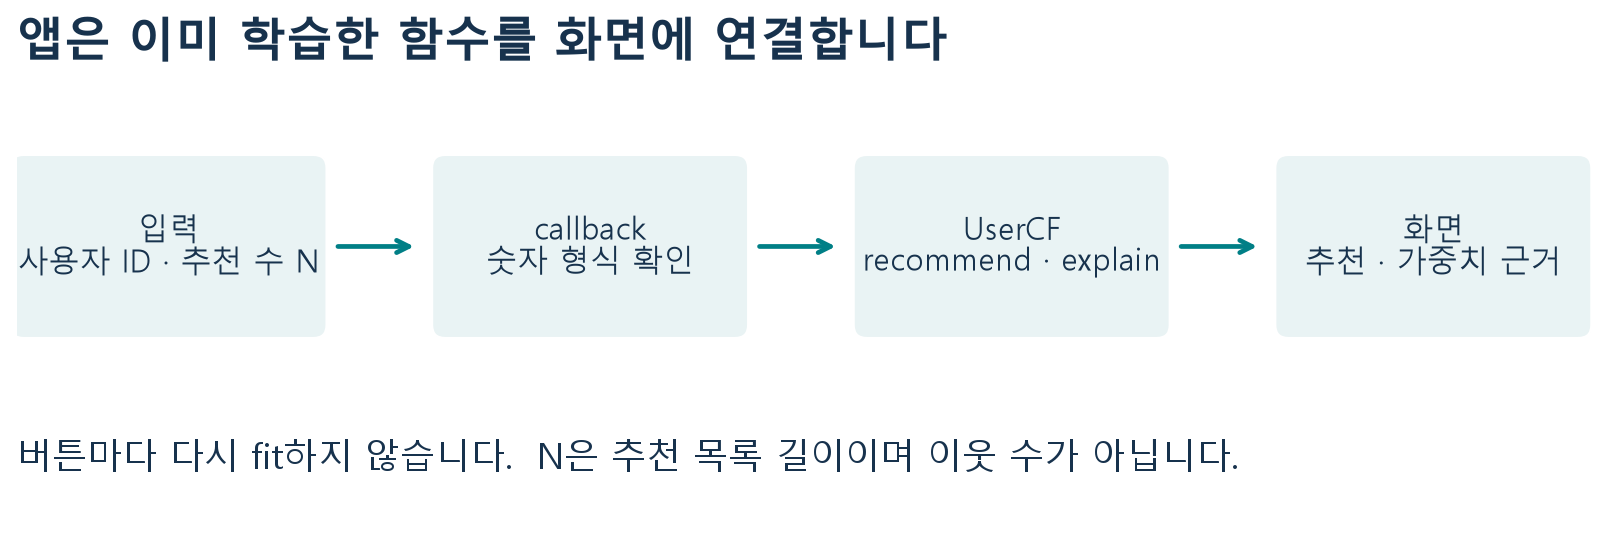


[Figure source](https://raw.githubusercontent.com/lunalab-ai/recommender/2026-fall-w03a/course/notion/assets/w03a/09-app-flow.png)


In [ ]:
import gradio as gr
from luna_recsys.cf_app import cf_view, build_cf_app

def show_cf(user_id, top_n):
    return cf_view(cf, data.movies, int(user_id), int(top_n))

summary, recommendations, evidence = show_cf(1, 5)
display(recommendations[["title", "prediction", "basis", "n_contributors"]])


### E7 · 버튼의 입력과 출력 연결하기
아래 화면에서 `inputs`와 `outputs`에 어떤 컴포넌트 목록을 넣을지 완성하라.
`show_cf`의 입력 순서와 세 반환값 순서를 먼저 확인한다.
`connection_inputs/connection_outputs`가 준비되면 `.click`이 연결된다.
미완성 앱 대신 다음 셀의 기준 앱으로 기능을 비교할 수 있다.


In [ ]:
with gr.Blocks() as exercise_app:
    ex_uid = gr.Dropdown(sorted(cf.seen_), value=1, label="사용자 ID")
    ex_n = gr.Slider(1, 20, value=5, step=1, label="추천 수")
    ex_button = gr.Button("추천")
    ex_summary, ex_rows, ex_evidence = gr.HTML(), gr.Dataframe(), gr.Dataframe()
    connection_inputs = None
    connection_outputs = None
    if connection_inputs is not None and connection_outputs is not None:
        ex_button.click(show_cf, inputs=connection_inputs, outputs=connection_outputs)


기준 앱은 이전 네 방법 비교 탭도 유지한다. `FourMethodRecommender().fit(train,
users,movies)`는 학습 평점과 사용자·장르 메타데이터로 이전 모델들을 준비한다.
`build_cf_app(cf,movies,comparison=...)`는 서버를 띄우기 전 Blocks를 반환한다.
Colab에서는 `launch(share=True)`로 공유 주소를 만든다. 주소는 실행 중인
런타임에 의존하므로 종료되면 다시 실행한다. 로컬에서는 앱을 구성하고
callback을 검사한다. 직접 화면을 열려면 다음 셀의 마지막 else 안에서
`app.launch()`를 실행한다. 자동 실행 검증은 서버를 계속 열어 두지 않는다.


In [ ]:
from luna_recsys.ranking import FourMethodRecommender

comparison = FourMethodRecommender().fit(train, data.users, data.movies)
app = build_cf_app(cf, data.movies, comparison=comparison)
if IN_COLAB:
    app.launch(share=True)
else:
    print("앱 구성 완료. 로컬 화면 확인: app.launch()")


### E8 · 두 사용자와 근거 비교
사용자 1과 2를 선택해 상위 5편의 제목·예측값·기여자 수를 비교하라.
첫 추천의 전체 기여도 합과 예측값이 같은지, 화면의 일부 근거 행만 합하면
왜 달라질 수 있는지 설명하라. 추천 수 N을 5에서 10으로 바꾸어도 같은
영화의 예측값이 달라지지 않는 이유를 적는다. 실제 결과를 근거로 쓰되
원본 사용자 속성이나 전체 평점 표를 공유 출력하지 않는다.


In [ ]:
for chosen_user in [1, 2]:
    _, selected_rows, _ = show_cf(chosen_user, 5)
    print("사용자", chosen_user)
    display(selected_rows[["title", "prediction", "n_contributors", "basis"]])
interpretation = None  # 관측한 공통점·차이점·근거 표시 범위를 문장으로 기록


## 실행 상태 확인
아래 검사는 문제 답안을 채우지 않아도 실제 데이터·분할·모델·앱 callback이
동작하는지 확인한다. callback 직접 호출은 실제 브라우저 조작 검증과 구별한다.
`basis`가 cf이면 설명에 사용한 평가자들은 모두 목표 영화의 train 평점을 가져야 한다.


In [ ]:
assert (len(data.users), len(data.movies), len(data.ratings)) == (943, 1682, 100000)
assert (len(train), len(test)) == (75000, 25000)
assert not train.duplicated(["user_id", "movie_id"]).any()
assert set(zip(train.user_id, train.movie_id)).isdisjoint(set(zip(test.user_id, test.movie_id)))
all_predictions = cf.predict(pairs)
assert np.isfinite(all_predictions).all() and ((all_predictions >= 1) & (all_predictions <= 5)).all()
assert np.allclose(all_predictions[:20], cf.predict(pairs.head(20).assign(rating=1)))
fallback = cf.predict_details(pd.DataFrame({"user_id":[-1], "movie_id":[-1]}))
assert fallback.iloc[0].basis == "global-mean" and np.isclose(fallback.iloc[0].prediction, train.rating.mean())
html, rows, shown_proof = show_cf(1, 5)
assert isinstance(html, str) and len(rows) == 5 and not shown_proof.empty
assert not set(rows.movie_id) & cf.seen_[1]
first_id = int(rows.iloc[0].movie_id)
full_proof = cf.explain(1, first_id)
assert set(full_proof.user_id) <= set(train.loc[train.movie_id == first_id, "user_id"])
assert np.isclose(full_proof.contribution.sum(), cf.predict(pd.DataFrame({"user_id":[1], "movie_id":[first_id]}))[0])
assert all(np.isfinite(row["RMSE"]) for row in metric_rows)
print("실제 데이터, 분리, 유한 예측, 대체 규칙, 추천 제외, 근거, callback 검사 통과")


## 점검 퀴즈
1. 내용 기반 추천과 협업 필터링은 각각 어떤 정보를 이용해 유사성을 판단하는가?
2. 미관측 평점을 코사인 계산용 행렬에서 0으로 채워도 실제 0점으로 평균에 넣으면 안 되는 이유는 무엇인가?
3. 전체 차원 코사인과 공통 평가 항목만으로 양쪽 노름을 계산한 코사인이 다른 값을 가질 수 있는 이유는 무엇인가?
4. Pearson 상관계수가 정의되지 않는 두 가지 상황은 무엇인가?
5. 두 행동 집합의 크기가 각각 4와 3이고 공통 항목이 2개라면 Jaccard 유사도는 얼마인가?
6. 기본 CF의 가중평균 분모에는 어떤 사용자의 유사도를 포함해야 하는가?
7. test 평점까지 포함하여 사용자 유사도를 계산한 뒤 같은 test로 RMSE를 구하면 왜 문제가 되는가?

## 가져갈 핵심
관측 마스크·유사도 정의·가중평균의 분모·학습/평가 분리를 함께 설명할 수 있어야 한다.
단일 holdout의 RMSE 개선과 실제 사용자 만족은 별개다. 다음 차시에는 이웃 선택을 다룬다.

## 참고문헌
- 임일(2025), 《AI 에이전트를 위한 개인화 추천 알고리즘》, 청람, 3.1–3.3.
- [scikit-learn 코사인](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html)
- [SciPy Pearson](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html)
- [SciPy Jaccard 거리](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.jaccard.html)
- [MovieLens 100K 공식 배포](https://grouplens.org/datasets/movielens/100k/)
- [scikit-learn 데이터 누수](https://scikit-learn.org/stable/common_pitfalls.html)
웹 출처 확인 2026-09-14. 그림·작은 데이터·실습 코드는 수업용 독자 제작이다.
